In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json
from groq import Groq
from google.colab import files

In [ ]:
client = Groq(
    api_key="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"
)

In [ ]:
uploaded = files.upload()

Saving client_hotel_review.csv to client_hotel_review.csv


In [ ]:
df = pd.read_csv("client_hotel_review.csv")

df.head()

,Tanggal,Platform,Rating,Review
0,2026-04-10,agoda.com,5,"Friendly staff, but the wifi connection was te..."
1,02-03-2026,Agoda,8.0 / 10,"kamar luas, view bagus. proses checkin juga sa..."
2,16/03/2026,agoda.com,3/10,overprice! ga sesuai foto. kamarnya sempit bgt...
3,2026-03-09,Agoda,2,Staff barely speaks English. Breakfast was awful.
4,2026-04-13,Traveloka,4.0,"overall bagus bgt, bersih dan nyaman. anak2 se..."


In [ ]:
df = df.dropna(subset=["Review"])
df = df.reset_index(drop=True)

df = df.head(100)

In [ ]:
aspects = ["Tangibility", "Reliability", "Responsiveness","Assurance", "Empathy" ]

In [ ]:
from httpx import Response
def analyze_review(review):
  prompt = f"""
You are a strict JSON generator.

Analyze sentiment for these aspects :
- Tangibility (room, cleanliness, wifi, amenities, facilities)
- Reliability (acuracy of service, matches description, price vs expectation)
- Responsiveness (speed of service, check in, check out, staff response)
- Assurance (staff profesionalism, communication, trust, language ability)
- Empathy (friendliness, politeness, care, helpfulness)

Rules :
- output MUST be valid JSON
- Do NOT include explanation
- Do NOT include text outside JSON
- Sentiment must be: Positive, Negative, Neutral
- If not mentioned → Neutral

Example output:
{{
"Tangibility":"Positive",
"Reliability":"Negative",
"Responsiveness":"Neutral",
"Assurance":"Positive",
"Empathy":"Neutral"
}}


Review: "{review}"

"""



  try:
      response = client.chat.completions.create(
          messages=[{"role": "user", "content": prompt}],
          model="llama-3.1-8b-instant",
          temperature=0
      )


      text = response.choices[0].message.content.strip()

      if "```" in text:
        text= text.replace("```json", "").replace("```", "").strip()


      start = text.find("{")
      end = text.rfind("}") + 1
      text = text[start:end]
      return json.loads(text)

  except:
    return {
            "Tangibility": "Neutral",
            "Reliability": "Neutral",
            "Responsiveness": "Neutral",
            "Assurance": "Neutral",
            "Empathy": "Neutral"
        }


In [ ]:
def analyze_review(review):
    prompt = f"""
You are a strict JSON generator.

Analyze sentiment of this hotel review:

Aspects:
- Tangibility
- Reliability
- Responsiveness
- Assurance
- Empathy

Rules:
- Output MUST be valid JSON only
- No explanation
- Sentiment: Positive, Negative, Neutral
- If not mentioned → Neutral

Example:
{{
"Tangibility":"Positive",
"Reliability":"Negative",
"Responsiveness":"Neutral",
"Assurance":"Positive",
"Empathy":"Neutral"
}}

Review: "{review}"
"""

    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.1-8b-instant",
            temperature=0
        )

        text = response.choices[0].message.content.strip()

        print("RAW:", text)

        if "```" in text:
            text = text.replace("```json", "").replace("```", "").strip()

        # ambil JSON saja
        start = text.find("{")
        end = text.rfind("}") + 1
        text = text[start:end]

        return json.loads(text)

    except Exception as e:
        print("ERROR:", e)

        return {
            "Tangibility": "Neutral",
            "Reliability": "Neutral",
            "Responsiveness": "Neutral",
            "Assurance": "Neutral",
            "Empathy": "Neutral"
        }

In [ ]:
analyze_review(df["Review"].iloc[0])

{'Tangibility': 'Negative',
 'Reliability': 'Negative',
 'Responsiveness': 'Neutral',
 'Assurance': 'Positive',
 'Empathy': 'Positive'}

In [ ]:
results = []


for review in tqdm(df["Review"]) :
  hasil = analyze_review(review)
  results.append(hasil)

aspect_df = pd.DataFrame(results)

df_final = pd.concat([df, aspect_df], axis=1)

df_final.head()

100%|██████████| 187/187 [07:08<00:00,  2.29s/it]


,Tanggal,Platform,Rating,Review,Tangibility,Reliability,Responsiveness,Assurance,Empathy
0,2026-04-10,agoda.com,5,"Friendly staff, but the wifi connection was te...",Negative,Negative,Neutral,Positive,Positive
1,02-03-2026,Agoda,8.0 / 10,"kamar luas, view bagus. proses checkin juga sa...",Positive,Neutral,Positive,Neutral,Neutral
2,16/03/2026,agoda.com,3/10,overprice! ga sesuai foto. kamarnya sempit bgt...,Negative,Negative,Neutral,Neutral,Neutral
3,2026-03-09,Agoda,2,Staff barely speaks English. Breakfast was awful.,Negative,Negative,Neutral,Negative,Negative
4,2026-04-13,Traveloka,4.0,"overall bagus bgt, bersih dan nyaman. anak2 se...",Positive,Neutral,Neutral,Neutral,Neutral


In [ ]:
mapping = {
    "Positive": 1,
    "Neutral": 0,
    "Negative": -1
}

for col in aspects:
    df_final[col + "_num"] = df_final[col].map(mapping)

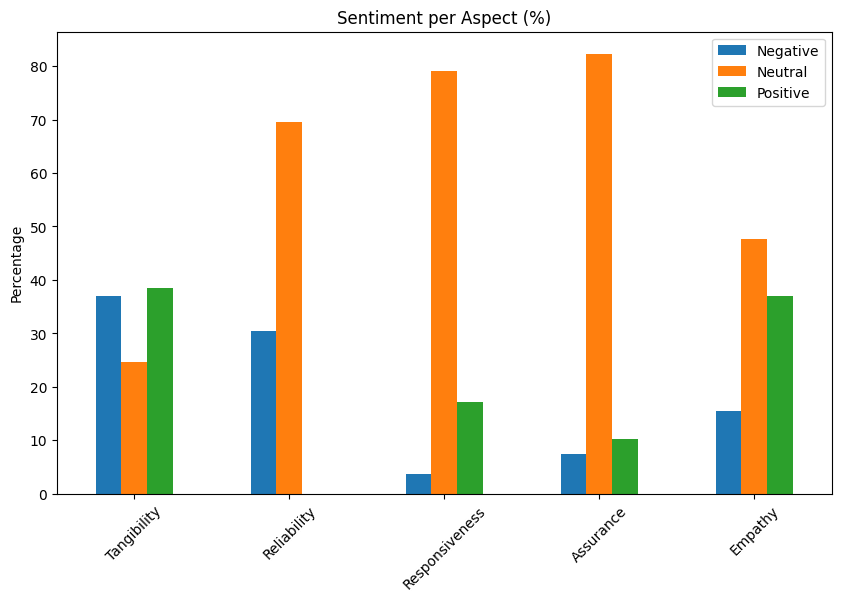

In [ ]:
sentiment_counts = {}

for aspect in aspects:
    sentiment_counts[aspect] = df_final[aspect].value_counts(normalize=True) * 100

sentiment_df = pd.DataFrame(sentiment_counts).T.fillna(0)

sentiment_df.plot(kind="bar", figsize=(10,6))
plt.title("Sentiment per Aspect (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

In [ ]:
def clean_rating(x):
    try:
        if isinstance(x, str) and "/" in x:
            return float(x.split("/")[0])
        return float(x)
    except:
        return None

df_final["Rating_clean"] = df_final["Rating"].apply(clean_rating)

In [ ]:
correlation = df_final[[col + "_num" for col in aspects] + ["Rating_clean"]].corr()

print(correlation["Rating_clean"])

Tangibility_num       0.630255
Reliability_num       0.566085
Responsiveness_num    0.337457
Assurance_num         0.247736
Empathy_num           0.577204
Rating_clean          1.000000
Name: Rating_clean, dtype: float64


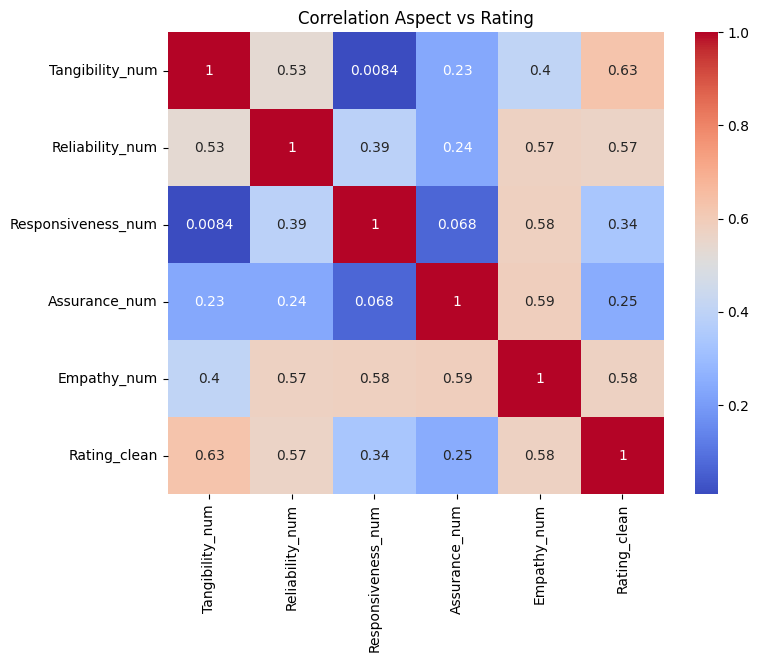

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Aspect vs Rating")
plt.show()